The last part of moddeling with (univariate spline) GAMs is choosing the smoothing parameter \\( \lambda \\). This post will elaborate on this, using the `scikit-learn` `GriddSearchCV` functionality to do this.

We'll use the same data as the last post

Text(0,0.5,'Acceleration')

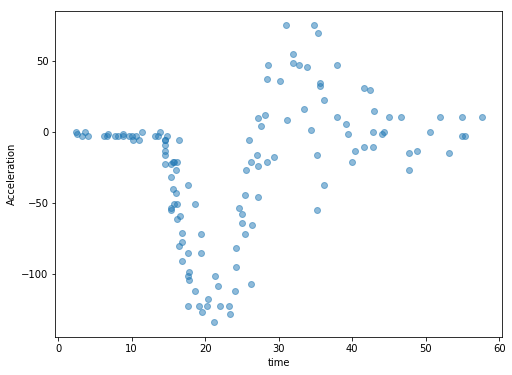

In [19]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import patsy
import scipy as sp
import seaborn as sns
from statsmodels import api as sm

%matplotlib inline

df = pd.read_csv('mcycle.csv')
df = df.drop('Unnamed: 0', axis=1)

min_time = df.times.min()
max_time = df.times.max()

fig, ax = plt.subplots(figsize=(8, 6))
blue = sns.color_palette()[0]
ax.scatter(df.times, df.accel, c=blue, alpha=0.5)
ax.set_xlabel('time')
ax.set_ylabel('Acceleration')

In [32]:
from sklearn.base import BaseEstimator

class SimpleGAM(BaseEstimator):
    
    def __init__(self, n_knots=20, gamma=1.0):
        self.n_knots = n_knots
        self.results = None
        self.gamma = gamma
    
    def fit(self, X, y, **kwargs):
        
        
        q = self.n_knots
        
        df_X = pd.DataFrame(data=X)
        df_y = pd.DataFrame(data=y)
        df = pd.concat([X, y], axis=1)
        knots = df.times.quantile(np.linspace(0, 1, q))
        y, X = patsy.dmatrices('y ~ X + self.R_(X)', data=df)
         
        
        S = np.zeros((q + 2, q + 2))
        S[2:, 2:] = self.R_(knots)
        
        B = np.zeros_like(S)
        B[2:, 2:] = np.real_if_close(sp.linalg.sqrtm(S[2:, 2:]), tol=10**8)
        
        y_ = np.vstack((y, np.zeros((q + 2, 1))))
        X_ = np.vstack((X, np.sqrt(self.gamma) * B))
    
        self.results = sm.OLS(y_, X_).fit()
        return self
    
    def R(self, x, z):
        return ((z - 0.5)**2 - 1 / 12) * ((x - 0.5)**2 - 1 / 12) / 4 - ((np.abs(x - z) - 0.5)**4 - 0.5 * (np.abs(x - z) - 0.5)**2 + 7 / 240) / 24

    def R_(self, x):
            return self.R.outer(x, knots).astype(np.float64)
    
    def predict(self, X):
        plot_X = patsy.dmatrix('times + R_(times)', {'times': X})
        return self.results.predict(plot_X)

In [33]:
gam = SimpleGAM()

In [34]:
gam.fit(df.times, df.accel)

PatsyError: Error evaluating factor: AttributeError: 'function' object has no attribute 'outer'
    y ~ X + self.R_(X)
            ^^^^^^^^^^

In [35]:
plot_x = np.linspace(min_time, max_time, 100)
preds = gam.predict(plot_x)

PatsyError: Error evaluating factor: NameError: name 'R_' is not defined
    times + R_(times)
            ^^^^^^^^^